# Pré-processamento

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Pré-processamento
df=pd.read_csv('Clean_Dataset.csv')
df.drop(columns=['ID','flight'],inplace=True) #talvez airline?

colunas_categoricas = ['airline','source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city','class']
df = df[df[colunas_categoricas].apply(lambda x: df.duplicated(subset=[x.name], keep=False)).all(axis=1)]

# df = pd.get_dummies(df, columns=[],drop_first=True)
print(df.columns)

xgb_fixed_params = {
    'n_estimators': 800,
    'learning_rate': 0.05,
    'max_depth': 12,             # Pulamos de 6 para 12. A árvore agora é gigantesca!
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 2,
    'random_state': 42,
    'n_jobs': -1
}

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price'],
      dtype='object')


# Execução (um modelo só)

In [ ]:
# Separação treino e teste
X = df.drop(columns=['price'])
y=df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous'), colunas_categoricas)
    ],
    remainder='passthrough' # Esta flag impede que as numéricas sejam apagadas ou encodadas
)

# O pipeline agora engloba o preprocessor e o modelo
pipeline_protegido = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42,n_jobs=-1))
])

In [49]:
# 1. Ajusta o pipeline final usando TODOS os dados de treino de uma vez só
print("Treinando o cérebro final do modelo...")
pipeline_protegido.fit(X_train, y_train)

# 2. Faz o teste real no seu X_test isolado (o "cofre" que ficou guardado)
previsoes_finais = pipeline_protegido.predict(X_test)
print("Modelo pronto e testado!")


Treinando o cérebro final do modelo...
Modelo pronto e testado!


In [ ]:
y_train_log = np.log1p(y_train)

# 2. Roda a validação cruzada prevendo o LOG do preço
y_pred_log = cross_val_predict(pipeline_protegido, X_train, y_train_log, cv=10, verbose=2)

# 3. Desfaz o logaritmo para calcular o erro real em Reais
y_pred_real = np.expm1(y_pred_log)

mae=mean_absolute_error(y_train,y_pred_real)
rmse=np.sqrt(mean_squared_error(y_train,y_pred_real))
r2=r2_score(y_train,y_pred_real)

print("\n========================================")
print("       RELATÓRIO DE MÉTRICAS (K=10)     ")
print("========================================")
print(f"MAE (Erro Médio Absoluto): R$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): R$ {rmse:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print("========================================")


       RELATÓRIO DE MÉTRICAS (K=10)     
MAE (Erro Médio Absoluto): R$ 1165.14
RMSE (Raiz do Erro Quadrático): R$ 2761.90
R² (Coeficiente de Determinação): 0.9852


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  6.1min finished


In [ ]:
def calculate_rmspe(y_true, y_pred):
    # (Real - Previsto) / Real -> Eleva ao quadrado -> Tira a média -> Tira a raiz
    erro_percentual_quadratico = np.square((y_true - y_pred) / y_true)
    return np.sqrt(np.mean(erro_percentual_quadratico))

# 1. Treinamos o pipeline FINAL usando todos os dados de treino limpos
print("Treinando o modelo final...")
y_train_log = np.log1p(y_train)
pipeline_protegido.fit(X_train, y_train_log)

# 2. Fazemos a previsão nos dados do COFRE (X_test_eco)
# Nota: Não removemos outliers do teste, porque no mundo real não podemos escolher os clientes!
y_pred_test_log = pipeline_protegido.predict(X_test)

# 3. Desfazemos o logaritmo
y_pred_test_real = np.expm1(y_pred_test_log)

# 4. Avaliamos o resultado final cego
mae_test = mean_absolute_error(y_test, y_pred_test_real)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_real))
r2_test = r2_score(y_test, y_pred_test_real)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test_real)
rmspe_test = calculate_rmspe(y_test, y_pred_test_real)

print("\n========================================")
print("     RESULTADO FINAL NO TESTE CEGO      ")
print("========================================")
print(f"MAE:   ₹ {mae_test:.2f}")
print(f"RMSE:  ₹ {rmse_test:.2f}")
print(f"R²:    {r2_test:.4f}")
print(f"MAPE:  {mape_test * 100:.2f}%")
print(f"RMSPE: {rmspe_test * 100:.2f}%")
print("========================================")

Treinando o modelo final...

     RESULTADO FINAL NO TESTE CEGO      
MAE:   ₹ 1157.08
RMSE:  ₹ 2764.32
R²:    0.9852
MAPE:  7.57%
RMSPE: 14.01%


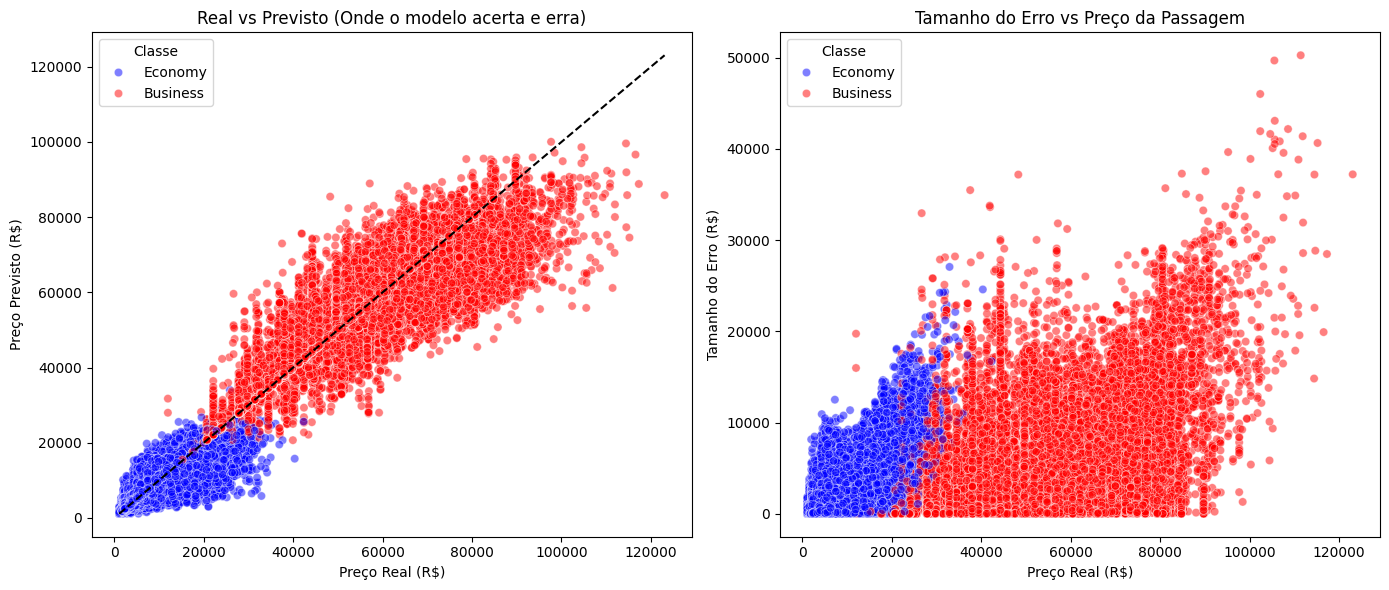


=== MAE (ERRO MÉDIO ABSOLUTO) ISOLADO POR CLASSE ===
Classe
Business    2465.439067
Economy      739.568032
Name: Erro Absoluto, dtype: float64


In [ ]:
# 1. Calcula o erro absoluto de cada predição individual
erros_absolutos = np.abs(y_train - y_pred)

# 2. Cria um DataFrame para facilitar a visualização cruzada
df_diagnostico = pd.DataFrame({
    'Preço Real': y_train,
    'Preço Previsto': y_pred,
    'Erro Absoluto': erros_absolutos,
    'Classe': X_train['class'] # Puxamos a classe para colorir o gráfico
})

# ==========================================
# GRÁFICO 1: Preço Real vs Preço Previsto
# ==========================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_diagnostico, x='Preço Real', y='Preço Previsto', hue='Classe', alpha=0.5, palette={'Economy': 'blue', 'Business': 'red'})
# Linha de perfeição (onde Real = Previsto)
plt.plot([df_diagnostico['Preço Real'].min(), df_diagnostico['Preço Real'].max()], 
         [df_diagnostico['Preço Real'].min(), df_diagnostico['Preço Real'].max()], 
         color='black', linestyle='--')
plt.title('Real vs Previsto (Onde o modelo acerta e erra)')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Previsto (R$)')

# ==========================================
# GRÁFICO 2: Distribuição dos Erros (Resíduos)
# ==========================================
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_diagnostico, x='Preço Real', y='Erro Absoluto', hue='Classe', alpha=0.5, palette={'Economy': 'blue', 'Business': 'red'})
plt.title('Tamanho do Erro vs Preço da Passagem')
plt.xlabel('Preço Real (R$)')
plt.ylabel('Tamanho do Erro (R$)')

plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISE MATEMÁTICA: Erro por Classe
# ==========================================
print("\n=== MAE (ERRO MÉDIO ABSOLUTO) ISOLADO POR CLASSE ===")
print(df_diagnostico.groupby('Classe')['Erro Absoluto'].mean())

# Pipeline economy

In [7]:
from sklearn.model_selection import train_test_split
# 1. Separa o DataFrame original em dois mundos totalmente isolados
df_economy = df[df['class'] == 'Economy'].copy()
# df_business = df[df['class'] == 'Business'].copy()

# 2. Agora você remove a coluna 'class' de ambos (já que ela virou constante)
df_economy.drop(columns=['class'], inplace=True)
# df_business.drop(columns=['class'], inplace=True)

X = df_economy.drop(columns=['price'])
y=df_economy['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train_eco, X_test_eco, y_train_eco, y_test_eco = train_test_split(X, y, test_size=0.1, random_state=42)

In [22]:
X_train_eco, X_test_eco, y_train_eco, y_test_eco = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder
colunas_categoricas_sem_class=colunas_categoricas.copy()
colunas_categoricas_sem_class.remove('class')
preprocessor_eco = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous'), colunas_categoricas_sem_class)
    ],
    remainder='passthrough' # Esta flag impede que as numéricas sejam apagadas ou encodadas
)

# O pipeline agora engloba o preprocessor e o modelo
pipeline_protegido_eco = Pipeline(steps=[
    ('preprocessor', preprocessor_eco),
    ('model', RandomForestRegressor(random_state=42,n_jobs=-1))
])

In [ ]:
y_train_log = np.log1p(y_train)

# 2. Roda a validação cruzada prevendo o LOG do preço
y_pred_log = cross_val_predict(pipeline_protegido_eco, X_train, y_train_log, cv=10, verbose=2)

# 3. Desfaz o logaritmo para calcular o erro real em Reais
y_pred_real = np.expm1(y_pred_log)

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_train,y_pred_real)
rmse=np.sqrt(mean_squared_error(y_train,y_pred_real))
r2=r2_score(y_train,y_pred_real)

print("\n========================================")
print("       RELATÓRIO DE MÉTRICAS (K=10)     ")
print("========================================")
print(f"MAE (Erro Médio Absoluto): ₹ {mae:.2f} ou R$ {mae*0.066:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): ₹ {rmse:.2f} ou R$ {rmse*0.066:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print("========================================")


       RELATÓRIO DE MÉTRICAS (K=10)     
MAE (Erro Médio Absoluto): ₹ 684.52 ou R$ 45.18
RMSE (Raiz do Erro Quadrático): ₹ 1507.44 ou R$ 99.49
R² (Coeficiente de Determinação): 0.8384


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  4.0min finished


In [14]:
import numpy as np

from sklearn.metrics import mean_absolute_percentage_error

def calculate_rmspe(y_true, y_pred):
    # (Real - Previsto) / Real -> Eleva ao quadrado -> Tira a média -> Tira a raiz
    erro_percentual_quadratico = np.square((y_true - y_pred) / y_true)
    return np.sqrt(np.mean(erro_percentual_quadratico))

mape = mean_absolute_percentage_error(y_train, y_pred_real)
rmspe = calculate_rmspe(y_train, y_pred_real)

print(f"Erro Percentual Absoluto (MAPE):  {mape * 100:.2f}%")
print(f"Erro Percentual Quadrático (RMSPE): {rmspe * 100:.2f}%")

Erro Percentual Absoluto (MAPE):  9.00%
Erro Percentual Quadrático (RMSPE): 16.11%


In [ ]:
# 1. Treinamos o pipeline FINAL usando todos os dados de treino limpos
print("Treinando o modelo final...")
pipeline_protegido_eco.fit(X_train, y_train_log)

# 2. Fazemos a previsão nos dados do COFRE (X_test_eco)
# Nota: Não removemos outliers do teste, porque no mundo real não podemos escolher os clientes!
y_pred_test_log = pipeline_protegido_eco.predict(X_test)

# 3. Desfazemos o logaritmo
y_pred_test_real = np.expm1(y_pred_test_log)

# 4. Avaliamos o resultado final cego
mae_test = mean_absolute_error(y_test, y_pred_test_real)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_real))
r2_test = r2_score(y_test, y_pred_test_real)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test_real)
rmspe_test = calculate_rmspe(y_test, y_pred_test_real)

print("\n========================================")
print("     RESULTADO FINAL NO TESTE CEGO      ")
print("========================================")
print(f"MAE:   ₹ {mae_test:.2f}")
print(f"RMSE:  ₹ {rmse_test:.2f}")
print(f"R²:    {r2_test:.4f}")
print(f"MAPE:  {mape_test * 100:.2f}%")
print(f"RMSPE: {rmspe_test * 100:.2f}%")
print("========================================")

Treinando o modelo final...

     RESULTADO FINAL NO TESTE CEGO      
MAE:   ₹ 628.09
RMSE:  ₹ 1397.68
R²:    0.8562
MAPE:  8.31%
RMSPE: 15.05%


# Pipeline bussiness

In [3]:
# 1. Separa o DataFrame original em dois mundos totalmente isolados
#df_economy = df[df['class'] == 'Economy'].copy()
df_business = df[df['class'] == 'Business'].copy()

# 2. Agora você remove a coluna 'class' de ambos (já que ela virou constante)
#df_economy.drop(columns=['class'], inplace=True)
df_business.drop(columns=['class'], inplace=True)

X = df_business.drop(columns=['price'])
y=df_business['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train_bus, X_test_bus, y_train_bus, y_test_bus = train_test_split(X, y, test_size=0.1, random_state=42)

In [4]:
colunas_categoricas_sem_class=colunas_categoricas.copy()
colunas_categoricas_sem_class.remove('class')
preprocessor_bus = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous'), colunas_categoricas_sem_class)
    ],
    remainder='passthrough' # Esta flag impede que as numéricas sejam apagadas ou encodadas
)

# O pipeline agora engloba o preprocessor e o modelo
pipeline_protegido_bus = Pipeline(steps=[
    ('preprocessor', preprocessor_bus),
    ('model', RandomForestRegressor(random_state=42,n_jobs=-1))
])

In [5]:
y_train_log = np.log1p(y_train)

# 2. Roda a validação cruzada prevendo o LOG do preço
y_pred_log = cross_val_predict(pipeline_protegido_bus, X_train, y_train_log, cv=10, verbose=2)

# 3. Desfaz o logaritmo para calcular o erro real em Reais
y_pred_real = np.expm1(y_pred_log)

mae=mean_absolute_error(y_train,y_pred_real)
rmse=np.sqrt(mean_squared_error(y_train,y_pred_real))
r2=r2_score(y_train,y_pred_real)

print("\n========================================")
print("       RELATÓRIO DE MÉTRICAS (K=10)     ")
print("========================================")
print(f"MAE (Erro Médio Absoluto): ₹ {mae:.2f} ou R$ {mae*0.066:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): ₹ {rmse:.2f} ou R$ {rmse*0.066:.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print("========================================")


       RELATÓRIO DE MÉTRICAS (K=10)     
MAE (Erro Médio Absoluto): ₹ 2026.55 ou R$ 133.75
RMSE (Raiz do Erro Quadrático): ₹ 4312.10 ou R$ 284.60
R² (Coeficiente de Determinação): 0.8894


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  1.1min finished


In [6]:
import numpy as np

from sklearn.metrics import mean_absolute_percentage_error

def calculate_rmspe(y_true, y_pred):
    # (Real - Previsto) / Real -> Eleva ao quadrado -> Tira a média -> Tira a raiz
    erro_percentual_quadratico = np.square((y_true - y_pred) / y_true)
    return np.sqrt(np.mean(erro_percentual_quadratico))

mape = mean_absolute_percentage_error(y_train, y_pred_real)
rmspe = calculate_rmspe(y_train, y_pred_real)

print(f"Erro Percentual Absoluto (MAPE):  {mape * 100:.2f}%")
print(f"Erro Percentual Quadrático (RMSPE): {rmspe * 100:.2f}%")

Erro Percentual Absoluto (MAPE):  3.50%
Erro Percentual Quadrático (RMSPE): 7.22%


In [7]:
# 1. Treinamos o pipeline FINAL usando todos os dados de treino limpos
print("Treinando o modelo final...")
pipeline_protegido_bus.fit(X_train, y_train_log)

# 2. Fazemos a previsão nos dados do COFRE (X_test_eco)
# Nota: Não removemos outliers do teste, porque no mundo real não podemos escolher os clientes!
y_pred_test_log = pipeline_protegido_bus.predict(X_test)

# 3. Desfazemos o logaritmo
y_pred_test_real = np.expm1(y_pred_test_log)

# 4. Avaliamos o resultado final cego
mae_test = mean_absolute_error(y_test, y_pred_test_real)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_real))
r2_test = r2_score(y_test, y_pred_test_real)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test_real)
rmspe_test = calculate_rmspe(y_test, y_pred_test_real)

print("\n========================================")
print("     RESULTADO FINAL NO TESTE CEGO      ")
print("========================================")
print(f"MAE:   ₹ {mae_test:.2f}")
print(f"RMSE:  ₹ {rmse_test:.2f}")
print(f"R²:    {r2_test:.4f}")
print(f"MAPE:  {mape_test * 100:.2f}%")
print(f"RMSPE: {rmspe_test * 100:.2f}%")
print("========================================")

Treinando o modelo final...

     RESULTADO FINAL NO TESTE CEGO      
MAE:   ₹ 2016.93
RMSE:  ₹ 4315.57
R²:    0.8893
MAPE:  3.44%
RMSPE: 7.01%


# Execução global

In [5]:
# =====================================================================
# 1. ISOLANDO OS DOIS MUNDOS 
# =====================================================================
df_economy = df[df['class'] == 'Economy'].copy()
df_business = df[df['class'] == 'Business'].copy()

# A coluna class não é mais necessária, pois já separamos os mundos
df_economy.drop(columns=['class'], inplace=True)
df_business.drop(columns=['class'], inplace=True)

# Separando X e y para cada classe
X_eco = df_economy.drop(columns=['price'])
y_eco = df_economy['price']

X_bus = df_business.drop(columns=['price'])
y_bus = df_business['price']

# =====================================================================
# 2. SEPARANDO O TREINO E O COFRE (TESTE CEGO 10%)
# =====================================================================
X_train_eco, X_test_eco, y_train_eco, y_test_eco = train_test_split(X_eco, y_eco, test_size=0.1, random_state=42)
X_train_bus, X_test_bus, y_train_bus, y_test_bus = train_test_split(X_bus, y_bus, test_size=0.1, random_state=42)

# =====================================================================
# 3. CONSTRUINDO OS PIPELINES (PREPROCESSADORES ISOLADOS)
# =====================================================================
colunas_categoricas_sem_class = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city']

# CRUCIAL: Criamos duas instâncias separadas para não haver sobreposição de memória!
preprocessor_eco = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous',random_state=42), colunas_categoricas_sem_class)
    ],
    remainder='passthrough'
)

preprocessor_bus = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(cv=10, target_type='continuous',random_state=42), colunas_categoricas_sem_class)
    ],
    remainder='passthrough'
)

from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from xgboost import XGBRegressor

# 1. Definimos os nossos "Especialistas" com os parâmetros Unleashed
estimadores_base = [
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(**xgb_fixed_params)) # Use o dicionário que criámos antes!
]

# 2. Criamos o "Gestor" (O Meta-Modelo que vai decidir quem tem razão)
# O RidgeCV é uma Regressão Linear robusta que aprende os pesos ideais
modelo_stacking_eco = StackingRegressor(
    estimators=estimadores_base,
    final_estimator=RidgeCV(),
    cv=5, # Faz validação cruzada interna para evitar overfitting
    n_jobs=1
)
from sklearn.base import clone
modelo_stacking_bus = clone(modelo_stacking_eco)

# 3. Colocamos o Stacking dentro do seu Pipeline existente!
pipeline_economy = Pipeline(steps=[
    ('preprocessor', preprocessor_eco),
    ('model', modelo_stacking_eco)
])

pipeline_business = Pipeline(steps=[
    ('preprocessor', preprocessor_bus),
    ('model', modelo_stacking_bus)
])

# =====================================================================
# 4. TREINAMENTO (APLICANDO LOG NO TARGET)
# =====================================================================
y_train_eco_log = np.log1p(y_train_eco)
y_train_bus_log = np.log1p(y_train_bus)

print("Treinando o modelo da classe Economy...")
pipeline_economy.fit(X_train_eco, y_train_eco_log)

print("Treinando o modelo da classe Business...")
pipeline_business.fit(X_train_bus, y_train_bus_log)

print("Treinamento de ambos os modelos concluído com sucesso!")

Treinando o modelo da classe Economy...
Treinando o modelo da classe Business...
Treinamento de ambos os modelos concluído com sucesso!


In [6]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def calculate_rmspe(y_true, y_pred):
    # (Real - Previsto) / Real -> Eleva ao quadrado -> Tira a média -> Tira a raiz
    erro_percentual_quadratico = np.square((y_true - y_pred) / y_true)
    return np.sqrt(np.mean(erro_percentual_quadratico))


# =====================================================================
# 1. PREVISÕES (TESTE CEGO E REVERSÃO DO LOGARITMO)
# =====================================================================
# Classe Economy
y_pred_eco_log = pipeline_economy.predict(X_test_eco)
y_pred_eco = np.expm1(y_pred_eco_log) # Trazendo de volta para Rúpias

# Classe Business
y_pred_bus_log = pipeline_business.predict(X_test_bus)
y_pred_bus = np.expm1(y_pred_bus_log) # Trazendo de volta para Rúpias

# =====================================================================
# 2. CONCATENANDO PARA A AVALIAÇÃO GLOBAL DO SISTEMA
# =====================================================================
y_test_total = np.concatenate([y_test_eco, y_test_bus])
y_pred_total = np.concatenate([y_pred_eco, y_pred_bus])

# =====================================================================
# 3. RELATÓRIO FINAL
# =====================================================================
mae_global = mean_absolute_error(y_test_total, y_pred_total)
rmse_global = np.sqrt(mean_squared_error(y_test_total, y_pred_total))
r2_global = r2_score(y_test_total, y_pred_total)
mape_global = mean_absolute_percentage_error(y_test_total, y_pred_total)
rmspe_global = calculate_rmspe(y_test_total, y_pred_total)

print("\n=== DESEMPENHO REAL DO SISTEMA SEGMENTADO (MUNDO REAL) ===")
print(f"MAE Global:  ₹ {mae_global:.2f} ou R$ {mae_global*0.066:.2f}")
print(f"RMSE Global:  ₹ {rmse_global:.2f} ou R$ {rmse_global*0.066:.2f}")
print(f"R² Global:   {r2_global:.4f}")
print(f"MAPE Global: {mape_global * 100:.2f}%")
print(f"RMSPE Global: {rmspe_global * 100:.2f}%")
print("==========================================================")


=== DESEMPENHO REAL DO SISTEMA SEGMENTADO (MUNDO REAL) ===
MAE Global:  ₹ 1085.00 ou R$ 71.61
RMSE Global:  ₹ 2484.62 ou R$ 163.98
R² Global:   0.9881
MAPE Global: 7.11%
RMSPE Global: 12.31%


# Análise de dados

In [7]:
#Listagem quantas categoricas
colunas_categoricas=['source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
contagem_classes = df[colunas_categoricas].nunique()
print(contagem_classes)

source_city         6
departure_time      6
stops               3
arrival_time        6
destination_city    6
class               2
dtype: int64


In [8]:
for coluna in colunas_categoricas:
    classes = df[coluna].unique()
    print(f"📌 Coluna '{coluna}':")
    print(classes)
    print("-" * 40) # Linha divisória para organizar

📌 Coluna 'source_city':
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
----------------------------------------
📌 Coluna 'departure_time':
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
----------------------------------------
📌 Coluna 'stops':
['zero' 'one' 'two_or_more']
----------------------------------------
📌 Coluna 'arrival_time':
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
----------------------------------------
📌 Coluna 'destination_city':
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
----------------------------------------
📌 Coluna 'class':
['Economy' 'Business']
----------------------------------------


In [15]:
import numpy as np

# Percorre cada coluna categórica
for coluna in colunas_categoricas:
    print(f"\n📊 ANÁLISE DA COLUNA: {coluna.upper()}")
    print("=" * 50)
    
    # 1. Conta a quantidade absoluta de elementos por classe
    contagem = df[coluna].value_counts()
    
    # 2. Calcula a porcentagem/distribuição de cada classe (multiplica por 100)
    porcentagem = df[coluna].value_counts(normalize=True) * 100
    
    # 3. Junta as duas informações em um único DataFrame para exibição rápida
    analise_coluna = pd.DataFrame({
        'Quantidade': contagem,
        'Distribuição (%)': porcentagem.round(2) # Arredonda para 2 casas decimais
    })
    
    print(analise_coluna)
    print("=" * 50)



📊 ANÁLISE DA COLUNA: SOURCE_CITY
             Quantidade  Distribuição (%)
source_city                              
Delhi             61343             20.44
Mumbai            60896             20.29
Bangalore         52061             17.34
Kolkata           46347             15.44
Hyderabad         40806             13.60
Chennai           38700             12.89

📊 ANÁLISE DA COLUNA: DEPARTURE_TIME
                Quantidade  Distribuição (%)
departure_time                              
Morning              71146             23.70
Early_Morning        66790             22.25
Evening              65102             21.69
Night                48015             16.00
Afternoon            47794             15.92
Late_Night            1306              0.44

📊 ANÁLISE DA COLUNA: STOPS
             Quantidade  Distribuição (%)
stops                                    
one              250863             83.58
zero              36004             12.00
two_or_more       13286              

In [9]:
from sklearn.ensemble import IsolationForest
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df_sem_cat=df.drop(columns=colunas_categoricas)
# scaler = StandardScaler()
# X_escalado = scaler.fit_transform(df_sem_cat)

iso_forest = IsolationForest(contamination=0.001, random_state=42, n_jobs=-1)
outliers = iso_forest.fit_predict(df_sem_cat)

df['is_outlier'] = (outliers == -1)

print("=== CONTAGEM DE OUTLIERS ===")
print(df['is_outlier'].value_counts())

df_10_outliers = df[df['is_outlier'] == True].head(10)
print(df_10_outliers)

=== CONTAGEM DE OUTLIERS ===
is_outlier
False    299852
True        301
Name: count, dtype: int64
      source_city departure_time        stops  ... days_left  price is_outlier
35402       Delhi        Morning  two_or_more  ...         1  18757       True
35403       Delhi        Morning  two_or_more  ...         1  18757       True
35407       Delhi  Early_Morning  two_or_more  ...         1  20071       True
35413       Delhi  Early_Morning  two_or_more  ...         1  23221       True
35499       Delhi        Morning  two_or_more  ...         2  18757       True
35504       Delhi        Morning  two_or_more  ...         2  19597       True
53017      Mumbai  Early_Morning          one  ...         2  21540       True
53030      Mumbai        Morning  two_or_more  ...         2  24531       True
70369      Mumbai        Morning  two_or_more  ...         1  17985       True
70430      Mumbai  Early_Morning          one  ...         2  10777       True

[10 rows x 10 columns]


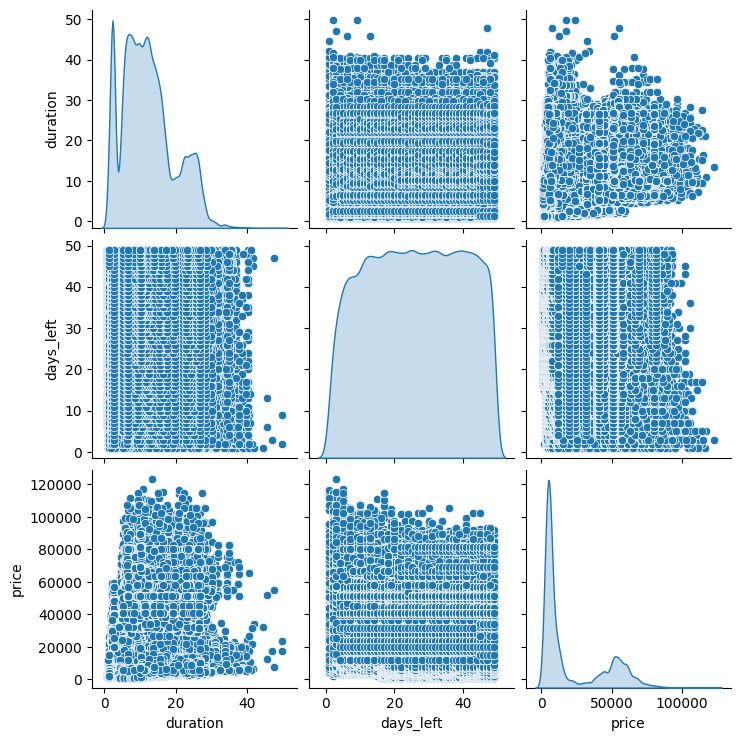

In [ ]:
# Mostra a distribuição e correlação de tudo junto
sns.pairplot(df, diag_kind='kde')
plt.show()

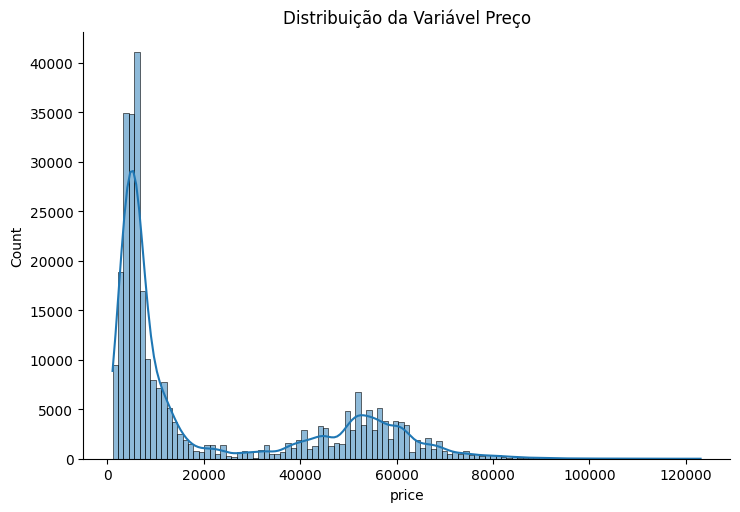

In [ ]:
# Substitua 'seu_target' pelo nome real da coluna alvo
sns.displot(data=df, x='price', kde=True, aspect=1.5)
plt.title('Distribuição da Variável Preço')
plt.show()


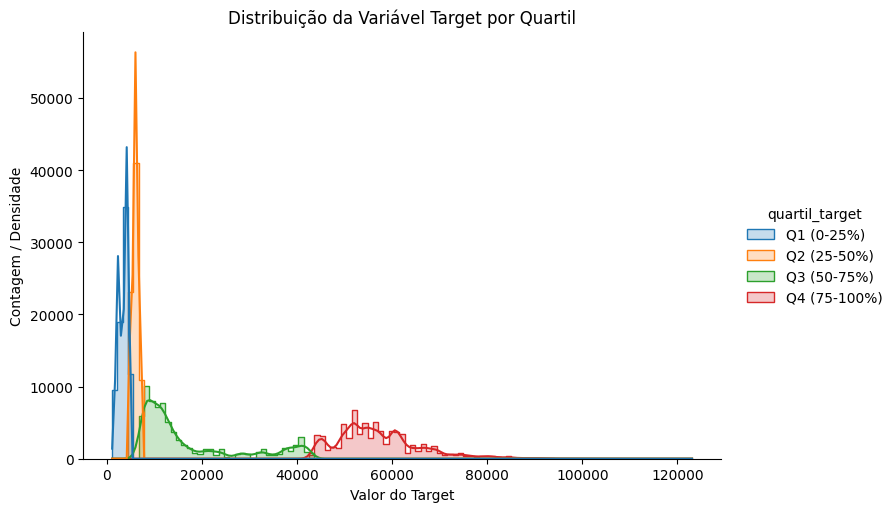

In [ ]:
# 1. Calcula os quartis e cria uma nova coluna identificando a qual quartil o dado pertence
df['quartil_target'] = pd.qcut(df['price'], q=4, labels=['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)'])

# 2. Plota o gráfico de distribuição separado pelas cores dos quartis
sns.displot(
    data=df, 
    x='price', 
    hue='quartil_target', 
    kde=True, 
    element='step',      # Evita que as barras fiquem sobrepostas e poluídas
    common_norm=False,   # Normaliza cada quartil individualmente para melhor visualização
    aspect=1.5
)

plt.title('Distribuição da Variável Target por Quartil')
plt.xlabel('Valor do Target')
plt.ylabel('Contagem / Densidade')
plt.show()

# 3. Limpa a coluna temporária se não quiser sujar seu df original
df.drop(columns=['quartil_target'], inplace=True)
